**Clustering Tipe Pengguna Media Sosial**

**Anggota Kelompok:**

1. Said Hasan Nasrallah (19250671) -Ketua 
2. Tata Dwi Tama Puta (19250729)
3. Shabryan Khaylani (19250936)
4. Hon Zie Kaori (19251001)
5. Sheren Putri Toisuta (19250707)

### 1. BUSSINES UNDERSTANDING


**a. Latar belakang Pemilihan Dataset:**


Penggunaan media sosial telah menjadi bagian yang tidak terpisahkan dari kehidupan masyarakat modern. Namun, di balik kemudahannya, penggunaan yang tidak terkontrol sering kali menimbulkan fenomena social media fatigue (kelelahan media sosial) dan dampak psikologis yang serius. Sebagaimana dinyatakan oleh (Putri & Aviani, 2023), penggunaan media sosial yang intensif dapat memicu peningkatan gejala stres pada individu akibat adanya ketidaksesuaian antara ekspektasi digital dengan kenyataan hidup yang dialami.
Masalah kesehatan mental seperti kecemasan, depresi, dan gangguan tidur kini menjadi perhatian serius dalam interaksi digital. Berbagai studi menunjukkan adanya keterkaitan antara durasi penggunaan media sosial dengan kondisi emosional penggunanya. Namun, setiap individu memiliki pola perilaku yang berbeda-beda — ada yang tetap stabil meski aktif menggunakan media sosial, namun ada juga yang sangat rentan terhadap dampak negatif meski durasi penggunaannya singkat. Hal ini menunjukkan bahwa belum adanya pengelompokan yang jelas mengenai tipe-tipe pengguna berdasarkan perilaku dan dampak kesehatan mental mereka, sehingga sulit untuk memahami karakteristik masing-masing tipe secara spesifik.
Dalam konteks Data Science, pendekatan Unsupervised Learning melalui algoritma Clustering memberikan solusi untuk mengelompokkan karakteristik pengguna tanpa memerlukan pelabelan manual. Hal ini sejalan dengan urgensi yang disampaikan oleh (Al Yasin, dkk., 2022), bahwa identifikasi dampak media sosial sangat penting sebagai langkah preventif untuk meminimalisir risiko kesehatan mental dan fisik jangka panjang. Oleh karena itu, penelitian ini memanfaatkan dataset Social Media and Mental Health yang berisi hasil survei terhadap 481 responden dengan 21 variabel, mencakup data demografi, kebiasaan penggunaan media sosial, serta dampaknya terhadap kesehatan mental. Dataset ini dianalisis menggunakan metode K-Means Clustering untuk menemukan pengelompokan alami tipe pengguna media sosial. Analisis ini diharapkan mampu memberikan kontribusi dalam memahami pola perilaku digital sekaligus mendukung upaya preventif terhadap dampak negatif penggunaan media sosial secara berlebihan.




**b. Tujuan**

Tujuan dari penelitian ini adalah:

1. Mengelompokkan pengguna media sosial berdasarkan perilaku penggunaan dan dampak kesehatan mental menggunakan algoritma K-Means Clustering
2. Mengidentifikasi karakteristik dan pola dari masing-masing tipe pengguna yang terbentuk
3. Memberikan insight mengenai hubungan antara intensitas penggunaan media sosial dengan kondisi kesehatan mental pengguna

**C. Manfaat**

- **Pengguna sosmed** — Dapat mengetahui mereka termasuk tipe pengguna yang mana dan mengevaluasi kebiasaan digital mereka sendiri
- **Platform sosmed** — Dapat mengembangkan fitur yang lebih sehat seperti *screen time reminder* yang ditargetkan untuk tipe *Heavy User*
- **Psikolog / Peneliti** — Dapat mengidentifikasi kelompok mana yang paling berisiko mengalami gangguan mental health akibat penggunaan media sosial

**d. Mengapa Menggunakan Clustering?**


Metode clustering dipilih karena dataset ini tidak memiliki label atau kategori pengguna yang sudah ditentukan sebelumnya. Tidak ada kolom yang bertuliskan "Heavy User" atau "Casual User" — kita tidak tahu dari awal ada berapa tipe pengguna dan siapa masuk ke tipe mana. Maka dari itu digunakan unsupervised learning yaitu K-Means Clustering yang bertugas menemukan pengelompokan alami dari data tanpa membutuhkan label.

In [1]:
import pandas as pd
file= "smmh.csv"
df=pd.read_csv(file)

Membaca File dan ubah jadi dataframe menggunakan Pandas

### 2. DATA UNDERSTANDING

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 21 columns):
 #   Column                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                --------------  -----  
 0   Timestamp                                                                                                             481 non-null    object 
 1   1. What is your age?                                                                                                  481 non-null    float64
 2   2. Gender                                                                                                             481 non-null    object 
 3   3. Relationship Status                                                                                                481 non-null    object 
 4   4. Occup



Berdasarkan hasil `df.info()`, dataset memiliki **481 data** dengan total **21 kolom**.

# a. Informasi Dataset
- `int64` : 12 kolom
- `object` : 8 kolom
- `float64` : 1 kolom

Terdapat missing value pada kolom:
- `What type of organizations are you affiliated with?`

karena jumlah non-null hanya **451 data**.

### Analisis Awal
Dataset berisi data mengenai:
- identitas responden,
- penggunaan media sosial,
- serta dampak psikologis yang dirasakan pengguna.

Beberapa kolom numerik nantinya digunakan dalam proses clustering menggunakan metode K-Means.

In [7]:
df.describe()

,1. What is your age?,9. How often do you find yourself using Social media without a specific purpose?,10. How often do you get distracted by Social media when you are busy doing something?,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
count,481.00000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000
mean,26.13659,3.553015,3.320166,2.588358,3.349272,3.559252,3.245322,2.831601,2.775468,2.455301,3.255717,3.170478,3.201663
std,9.91511,1.096299,1.328137,1.257059,1.175552,1.283356,1.347105,1.407835,1.056479,1.247739,1.313033,1.256666,1.461619
min,13.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,21.00000,3.000000,2.000000,2.000000,3.000000,3.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000
50%,22.00000,4.000000,3.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000
75%,26.00000,4.000000,4.000000,3.000000,4.000000,5.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,5.000000
max,91.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


## b. Statistik Deskriptif Dataset

Berdasarkan hasil statistik deskriptif (`describe()`), dataset memiliki total **481 responden** pada setiap kolom numerik.

### Hasil Analisis Awal

- Rata-rata umur responden adalah sekitar **26 tahun**.
- Nilai rata-rata pada beberapa fitur seperti:
  - penggunaan media sosial tanpa tujuan,
  - distraksi,
  - kekhawatiran,
  - dan gangguan tidur

  berada di kisaran **3** dari skala 1–5, yang menunjukkan bahwa responden cukup sering mengalami dampak penggunaan media sosial.

- Nilai minimum pada sebagian besar fitur adalah **1**, sedangkan nilai maksimum mencapai **5**, sesuai dengan skala kuesioner yang digunakan.

- Standar deviasi pada tiap fitur berkisar antara **1.0 – 1.4**, yang menunjukkan adanya variasi jawaban antar responden.

### Kesimpulan Sementara

Berdasarkan statistik deskriptif, data menunjukkan adanya variasi perilaku dan kondisi psikologis pengguna media sosial. Oleh karena itu, dataset cukup relevan untuk dilakukan proses clustering guna menemukan pola kelompok pengguna media sosial.

In [21]:
print(f"Mengecek Jumlah Missing Value di tiap kolom\n {df.isnull().sum()} \n")
print(f"Apakah ada nilai unik di tiap baris? \n {df.duplicated().sum()}\n")

Mengecek Jumlah Missing Value di tiap kolom
 Timestamp                                                                                                                0
1. What is your age?                                                                                                     0
2. Gender                                                                                                                0
3. Relationship Status                                                                                                   0
4. Occupation Status                                                                                                     0
5. What type of organizations are you affiliated with?                                                                  30
6. Do you use social media?                                                                                              0
7. What social media platforms do you commonly use?                                           

## c. cek Kualitas Data

Pada tahap ini dilakukan pengecekan terhadap missing value dan data duplikat pada dataset.

### Hasil Pengecekan Missing Value

Berdasarkan hasil pengecekan, hampir seluruh kolom tidak memiliki missing value. Namun, terdapat missing value pada kolom:

- `What type of organizations are you affiliated with?`

sebanyak **30 data kosong**.

### Hasil Pengecekan Data Duplikat

Hasil pengecekan menunjukkan bahwa:
- jumlah data duplikat = **0**

Sehingga tidak ditemukan baris data yang terduplikasi pada dataset.

### Kesimpulan

Dataset secara umum memiliki kualitas data yang cukup baik karena:
- sebagian besar kolom tidak memiliki missing value,
- dan tidak ditemukan data duplikat.

Namun, kolom yang memiliki missing value perlu ditangani pada tahap preprocessing sebelum proses clustering dilakukan.

In [18]:
df.nunique()

Timestamp                                                                                                               480
1. What is your age?                                                                                                     46
2. Gender                                                                                                                 9
3. Relationship Status                                                                                                    4
4. Occupation Status                                                                                                      4
5. What type of organizations are you affiliated with?                                                                   18
6. Do you use social media?                                                                                               2
7. What social media platforms do you commonly use?                                                                     125
8. What 

### 3. DATA PREPARATION

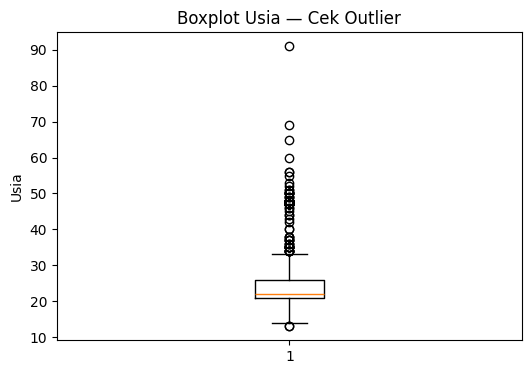

Batas bawah: 13.5
Batas atas : 33.5
Jumlah outlier: 84
     1. What is your age?
19                   34.0
25                   35.0
27                   35.0
31                   35.0
42                   56.0
..                    ...
460                  50.0
463                  13.0
465                  13.0
472                  35.0
480                  53.0

[84 rows x 1 columns]


In [22]:
import matplotlib.pyplot as plt

# Boxplot cek outlier kolom usia
plt.figure(figsize=(6, 4))
plt.boxplot(df['1. What is your age?'].dropna())
plt.title('Boxplot Usia — Cek Outlier')
plt.ylabel('Usia')
plt.show()

# IQR Method — hitung batas outlier
Q1 = df['1. What is your age?'].quantile(0.25)
Q3 = df['1. What is your age?'].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas  = Q3 + 1.5 * IQR

outlier = df[(df['1. What is your age?'] < batas_bawah) | 
             (df['1. What is your age?'] > batas_atas)]

print(f'Batas bawah: {batas_bawah}')
print(f'Batas atas : {batas_atas}')
print(f'Jumlah outlier: {len(outlier)}')
print(outlier[['1. What is your age?']])

In [23]:
df = df[(df['1. What is your age?'] >= batas_bawah) & 
        (df['1. What is your age?'] <= batas_atas)]

print(f'Shape setelah hapus outlier: {df.shape}')

Shape setelah hapus outlier: (397, 21)


In [11]:
kolom_baru = {
    'Timestamp': 'waktu',
    '1. What is your age?': 'umur',
    '2. Gender': 'kelamin',
    '3. Relationship Status': 'status umum',
    '4. Occupation Status': 'status pekerjaan',
    '5. What type of organizations are you affiliated with?': 'organisasi yang terhubung',
    '6. Do you use social media?': 'apakah kamu pengguna media sosial?',
    '7. What social media platforms do you commonly use?': 'platform media sosial',
    '8. What is the average time you spend on social media every day?': 'rata-rata waktu penggunaan media sosial per hari',
    '9. How often do you find yourself using Social media without a specific purpose?': 'scroll tanpa tujuan',
    '10. How often do you get distracted by Social media when you are busy doing something?': 'distraksi sosmed',
    "11. Do you feel restless if you haven't used Social media in a while?": 'ketergantungan sosmed',
    '12. On a scale of 1 to 5, how easily distracted are you?' : 'mudah_terdistraksi',
    '13. On a scale of 1 to 5, how much are you bothered by worries?' : 'kekhawatiran',
    '14. Do you find it difficult to concentrate on things?' : 'kesulitan konsentrasi',
    '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?' : 'perbandingan diri sosmed',
    '16. Following the previous question, how do you feel about these comparisons, generally speaking?' : 'dampak perbandingan',
    '17. How often do you look to seek validation from features of social media?' : 'haus validasi',
    '18. How often do you feel depressed or down?' : 'depresi',
    '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?' : 'mood tidak stabil',
    '20. On a scale of 1 to 5, how often do you face issues regarding sleep?' : 'gangguan tidur',
}

df.rename(columns=kolom_baru, inplace=True)
df.head(2).T

,0,1
waktu,4/18/2022 19:18:47,4/18/2022 19:19:28
umur,21.0,21.0
kelamin,Male,Female
status umum,In a relationship,Single
status pekerjaan,University Student,University Student
organisasi yang terhubung,University,University
apakah kamu pengguna media sosial?,Yes,Yes
platform media sosial,"Facebook, Twitter, Instagram, YouTube, Discord...","Facebook, Twitter, Instagram, YouTube, Discord..."
rata-rata waktu penggunaan media sosial per hari,Between 2 and 3 hours,More than 5 hours
scroll tanpa tujuan,5,4


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 21 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   waktu                                             481 non-null    object 
 1   umur                                              481 non-null    float64
 2   kelamin                                           481 non-null    object 
 3   status umum                                       481 non-null    object 
 4   status pekerjaan                                  481 non-null    object 
 5   organisasi yang terhubung                         451 non-null    object 
 6   apakah kamu pengguna media sosial?                481 non-null    object 
 7   platform media sosial                             481 non-null    object 
 8   rata-rata waktu penggunaan media sosial per hari  481 non-null    object 
 9   scroll tanpa tujuan  

📌 Ukuran Dataset
- 481 baris
- 21 kolom

🧠 Tipe Data
- float64: 1 kolom
- int64: 12 kolom
- object: 8 kolom

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
umur,481.0,26.136590,9.915110,13.0,21.0,22.0,26.0,91.0
scroll tanpa tujuan,481.0,3.553015,1.096299,1.0,3.0,4.0,4.0,5.0
distraksi sosmed,481.0,3.320166,1.328137,1.0,2.0,3.0,4.0,5.0
ketergantungan sosmed,481.0,2.588358,1.257059,1.0,2.0,2.0,3.0,5.0
mudah_terdistraksi,481.0,3.349272,1.175552,1.0,3.0,3.0,4.0,5.0
kekhawatiran,481.0,3.559252,1.283356,1.0,3.0,4.0,5.0,5.0
kesulitan konsentrasi,481.0,3.245322,1.347105,1.0,2.0,3.0,4.0,5.0
perbandingan diri sosmed,481.0,2.831601,1.407835,1.0,2.0,3.0,4.0,5.0
dampak perbandingan,481.0,2.775468,1.056479,1.0,2.0,3.0,3.0,5.0
haus validasi,481.0,2.455301,1.247739,1.0,1.0,2.0,3.0,5.0


- `count`: 481 baris valid
- `mean`: nilai rata-rata
- `std`: sebaran data
- `min`/`max`: nilai terkecil/terbesar
- `age`: mayoritas 20-an tahun
- pertanyaan 9–20: jawaban cenderung di kisaran 2–4

In [14]:
df.isnull().sum()

waktu                                                0
umur                                                 0
kelamin                                              0
status umum                                          0
status pekerjaan                                     0
organisasi yang terhubung                           30
apakah kamu pengguna media sosial?                   0
platform media sosial                                0
rata-rata waktu penggunaan media sosial per hari     0
scroll tanpa tujuan                                  0
distraksi sosmed                                     0
ketergantungan sosmed                                0
mudah_terdistraksi                                   0
kekhawatiran                                         0
kesulitan konsentrasi                                0
perbandingan diri sosmed                             0
dampak perbandingan                                  0
haus validasi                                        0
depresi   

### Pemeriksaan Missing Value (`df.isnull().sum()`)

`df.isnull().sum()` menghitung berapa nilai kosong (`NaN`) di setiap kolom DataFrame.

- `Timestamp`: 0
- `1. What is your age?`: 0
- `2. Gender`: 0
- `3. Relationship Status`: 0
- `4. Occupation Status`: 0
- `5. What type of organizations are you affiliated with?`: 30
- `6. Do you use social media?`: 0
- `7. What social media platforms do you commonly use?`: 0
- `8. What is the average time you spend on social media every day?`: 0
- `9. How often do you find yourself using Social media without a specific purpose?`: 0
- `10. How often do you get distracted by Social media when you are busy doing something?`: 0
- `11. Do you feel restless if you haven't used Social media in a while?`: 0
- `12. On a scale of 1 to 5, how easily distracted are you?`: 0
- `13. On a scale of 1 to 5, how much are you bothered by worries?`: 0
- `14. Do you find it difficult to concentrate on things?`: 0
- `15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?`: 0
- `16. Following the previous question, how do you feel about these comparisons, generally speaking?`: 0
- `17. How often do you look to seek validation from features of social media?`: 0
- `18. How often do you feel depressed or down?`: 0
- `19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?`: 0
- `20. On a scale of 1 to 5, how often do you face issues regarding sleep?`: 0

**Kesimpulan singkat:**
- Hanya kolom `5. What type of organizations are you affiliated with?` yang memiliki missing value.
- Jumlah missing di kolom tersebut: `30`.
- Kolom lain lengkap tanpa nilai kosong.

In [15]:
df.nunique()

waktu                                               480
umur                                                 46
kelamin                                               9
status umum                                           4
status pekerjaan                                      4
organisasi yang terhubung                            18
apakah kamu pengguna media sosial?                    2
platform media sosial                               125
rata-rata waktu penggunaan media sosial per hari      6
scroll tanpa tujuan                                   5
distraksi sosmed                                      5
ketergantungan sosmed                                 5
mudah_terdistraksi                                    5
kekhawatiran                                          5
kesulitan konsentrasi                                 5
perbandingan diri sosmed                              5
dampak perbandingan                                   5
haus validasi                                   

### Analisis Jumlah Nilai Unik (`df.nunique()`)

`df.nunique()` menunjukkan berapa banyak nilai berbeda yang ada di setiap kolom.

- `Platforms used`: 125 nilai unik
  - artinya setiap responden memakai kombinasi platform yang sangat beragam
  - kolom ini sulit dipakai langsung untuk clustering
- kolom kategorikal lain seperti `Gender`, `Relationship Status`, dan `Occupation Status` cenderung memiliki nilai unik lebih sedikit
  - sehingga lebih mudah untuk di-encode menjadi angka

Kesimpulan:
- Kolom dengan nilai unik yang sangat banyak biasanya perlu direduksi atau dikelompokkan kembali.
- Untuk analisis clustering, kolom seperti `Platforms used` perlu ditangani khusus agar tidak menambah kompleksitas yang berlebihan.

In [16]:
print(df['2. Gender'].value_counts())


KeyError: '2. Gender'

In [ ]:
df['2. Gender'] = df['2. Gender'].apply(lambda x: x if x in ["Male","Female"] else "other")
print("\n")
print(df['2. Gender'].value_counts())



2. Gender
Female    263
Male      211
other       7
Name: count, dtype: int64


**2. DATA PREPERATION**

### Menghapus Kolom yang Tidak Relevan

Sebelum melakukan clustering, kolom-kolom berikut dihapus karena tidak mendukung analisis:

- `Timestamp`: hanya mencatat waktu pengisian survei, bukan perilaku atau kondisi pengguna.
- `5. What type of organizations are you affiliated with?`: memiliki banyak nilai kosong dan kurang relevan untuk pengelompokan.
- `7. What social media platforms do you commonly use?`: berisi kombinasi platform yang sangat beragam sehingga sulit diproses langsung.
- `6. Do you use social media?`: hampir semua responden menjawab sama, sehingga tidak memberikan variasi informasi.

Setelah penghapusan, `df.info()` dijalankan kembali untuk memastikan struktur data yang tersisa.

In [ ]:
df.drop(columns=["Timestamp","5. What type of organizations are you affiliated with?","7. What social media platforms do you commonly use?","6. Do you use social media?"], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 17 columns):
 #   Column                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                --------------  -----  
 0   1. What is your age?                                                                                                  481 non-null    float64
 1   2. Gender                                                                                                             481 non-null    object 
 2   3. Relationship Status                                                                                                481 non-null    object 
 3   4. Occupation Status                                                                                                  481 non-null    object 
 4   8. What 

**Alasan penghapusan:**

- Timestamp, hanya mencatat waktu pengisian survei, dan tidak berhubungan dengan perilaku atau kondisi mental pengguna

- 5. What type of organizations are you affiliated with?,  memiliki banyak nilai kosong, dan kurang relevan untuk pengelompokan pengguna

- 7. What social media platforms do you commonly use?, berisi kombinasi platform yang sangat beragam, dan sulit diolah langsung dalam analisis clustering

- 6. Do you use social media?, hampir semua responden menjawab sama, dan tidak memberikan nilai yang membedakan klaster

Hasil:
dataset menjadi lebih ringkas
hanya menyisakan fitur yang lebih relevan untuk clustering
df.info() digunakan kembali untuk memastikan perubahan struktur data

In [ ]:
kolom_baru={
    
}

In [ ]:
waktu_penggunaan = {
    'Less than an Hour': 1,
    'Between 1 and 2 hours': 2,
    'Between 2 and 3 hours': 3,
    'Between 3 and 4 hours': 4,
    'Between 4 and 5 hours': 5,
    'More than 5 hours': 6
}
df['8. What is the average time you spend on social media every day?'] = df['8. What is the average time you spend on social media every day?'].map(waktu_penggunaan)
df.head(10)

,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,10. How often do you get distracted by Social media when you are busy doing something?,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,21.0,Male,In a relationship,University Student,3,5,3,2,5,2,5,2,3,2,5,4,5
1,21.0,Female,Single,University Student,6,4,3,2,4,5,4,5,1,1,5,4,5
2,21.0,Female,Single,University Student,4,3,2,1,2,5,4,3,3,1,4,2,5
3,21.0,Female,Single,University Student,6,4,2,1,3,5,3,5,1,2,4,3,2
4,21.0,Female,Single,University Student,3,3,5,4,4,5,5,3,3,3,4,4,1
5,22.0,Female,Single,University Student,3,4,4,2,3,4,3,4,4,3,3,2,4
6,21.0,Female,Married,University Student,4,4,3,2,2,4,3,5,3,4,5,5,3
7,21.0,Female,In a relationship,University Student,6,5,2,3,3,3,1,1,3,1,5,5,1
8,21.0,Female,In a relationship,University Student,6,5,2,3,3,1,1,1,3,1,5,5,1
9,20.0,Male,Single,University Student,1,1,1,1,1,1,1,1,1,1,1,1,1
